# Fabrication-aware modeling of a diamond nanobeam photonic crystal cavity

**Author: Alessandro Buzzi, MIT**

[![Tidy3D](https://img.shields.io/badge/Tidy3D-2.x-blue)](https://docs.flexcompute.com/projects/tidy3d/en/latest/)  [![Python 3.10+](https://img.shields.io/badge/Python-3.10%2B-green)](https://python.org)  [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)

---

This notebook demonstrates a **fabrication-aware Tidy3D workflow** for simulating and characterizing a diamond photonic crystal nanobeam cavity near the **tin-vacancy (SnV)** spectral range. Using cavity and hole specifications embedded directly in the notebook, it combines a broadband resonance search with a narrowband characterization simulation to extract the resonance wavelength, Q factor, mode volume, Purcell factor, collection efficiency, and far-field / polarization response.

The notebook is self-contained and can be read independently of the associated fabrication study in [arXiv:2601.20025](https://arxiv.org/abs/2601.20025), where related SEM-derived cavity parameters are used in a broader statistical workflow.

### Practical Note

- Inputs: embedded cavity and hole geometry specifications, plus the measured thickness and sidewall angle
- Outputs: resonance wavelength, Q factor, near field, mode volume, Purcell factor, collection efficiency, and far-field / polarization observables
- Cached HDF5 results can be reused when present, so cloud reruns are optional

### What You Will Learn

- Generate notebook-local cavity geometry for simulation
- Run a broadband scout simulation to locate the cavity resonance
- Refine the response with a narrowband characterization simulation
- Extract Q, mode volume, Purcell factor, collection efficiency, and far-field / polarization observables

### Device at a Glance

| Parameter | Value |
|-----------|-------|
| Material | Diamond (n ≈ 2.41 @ 640 nm) |
| Slab thickness | 136 nm |
| Target wavelength | ~615–645 nm |
| Sidewall angle | 15.6° (fabrication taper) |
| Cavity type | Nanobeam photonic crystal |

## Background

Diamond photonic crystal nanobeam cavities are a useful platform for **solid-state quantum photonics** because they can combine small optical mode volumes with high quality factors, making them attractive for enhancing light-matter interaction with color centers such as **SnV** through the **Purcell effect**:

$$F_P = \frac{3}{4\pi^2} \left(\frac{\lambda_0}{n}\right)^3 \frac{Q}{V_{\text{eff}}}$$

where $Q$ is the quality factor, $V_{\text{eff}}$ the effective mode volume, $\lambda_0$ the free-space resonance wavelength, and $n$ the refractive index at the emitter site.

In this notebook, we take one fabricated cavity instance, treat its measured thickness, sidewall angle, cavity outline, and hole pattern as fixed inputs, and resolve its optical response with a two-stage FDTD workflow.

The emphasis here is the reusable simulation procedure itself: generate a fabrication-aware cavity geometry inside the notebook, identify the resonance with a broadband scout run, and then characterize the mode in detail with a narrowband simulation. The same workflow can also be embedded in larger SEM-based fabrication-analysis pipelines, but that broader context is secondary in this notebook.

### Simulation Workflow

We use a **two-stage FDTD approach** to balance computational cost with accuracy:

| Stage | Bandwidth | Monitors | Purpose |
|-------|-----------|----------|---------|
| **Scout** | 12 % (broadband) | point probe | Locate resonance; extract Q and decay time |
| **Lock-in** | 2 % (narrowband) | near-field, 3-D field, far-field | Mode volume, collection efficiency, polarization |

The scout stage uses a short, broad Gaussian pulse to excite all cavity modes in the spectral window; the time-domain ringdown is decomposed into decaying sinusoids using Prony's method (Tidy3D [ResonanceFinder](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.resonance.ResonanceFinder.html)). The detected resonance wavelength then seeds the lock-in stage, which resolves the cavity mode in detail.

## Table of Contents

1. [Imports and Configuration](#imports)
2. [Define the Diamond Material Model](#material)
3. [Generate Local Cavity Geometry](#geometry)
4. [Run a Broadband Resonance Search](#scout)
5. [Extract the Cavity Q-Factor](#qfactor)
6. [Run a Narrowband Characterization Simulation](#lockin)
7. [Near-Field Mode Analysis](#nearfield)
8. [Mode Volume and Purcell Enhancement](#modevolume)
9. [Far-Field Radiation and Collection Efficiency](#farfield)
10. [Polarization Analysis](#polarization)
11. [Results Summary](#summary)

<img src="img/DiamondPC.png" alt="diagram" width="550"/>

<a id='imports'></a>
## 1. Imports and Configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
from scipy.optimize import curve_fit
from scipy.signal import hilbert

import tidy3d as td
from tidy3d.plugins.resonance import ResonanceFinder
import gdstk

warnings.filterwarnings("ignore")

print(f"tidy3d version: {td.__version__}")

16:33:05 W. Europe Daylight Time INFO: Using client version: 2.11.2

tidy3d version: 2.11.2


In [2]:
# ── Physical parameters ───────────────────────────────────────────────────────
THICKNESS_UM = 0.136  # Diamond slab thickness [µm]
WAVELENGTH_SCOUT = 0.630  # Broadband centre wavelength [µm]  (630 nm)
SIDEWALL_ANGLE_DEG = 15.6  # Fabrication sidewall angle [degrees]
NA = 0.65  # Collection numerical aperture
N_BG = 1.0  # Background refractive index (air)
C0 = 299_792_458.0  # Speed of light [m/s]

# ── Notebook-local runtime paths and embedded geometry ──────────────────────
# This notebook can generate its own GDS files from explicit cavity and hole
# specs, so no external geometry files are required.
RUNTIME_ROOT = Path.cwd().resolve() / "tidy3d_diamond_photonic_cavity_runtime"
GDS_DIR = RUNTIME_ROOT / "gds"
RESULTS_DIR = RUNTIME_ROOT / "data" / "results"
GDS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CAVITY_BBOX_UM = (-15.675, -0.157, 15.675, 0.157)
HOLE_X_POSITIONS_UM = np.array(
    [
        -9.831,
        -9.63,
        -9.429,
        -9.228,
        -9.027,
        -8.826,
        -8.625,
        -8.424,
        -8.223,
        -8.022,
        -7.821,
        -7.62,
        -7.4195,
        -7.2185,
        -7.0175,
        -6.8165,
        -6.6165,
        -6.4175,
        -6.2185,
        -6.0215,
        -5.8265,
        -5.6325,
        -5.4405,
        -5.2495,
        -5.0605,
        -4.8715,
        -4.6705,
        -4.4695,
        -4.2685,
        -4.0675,
        -3.8665,
        -3.6655,
        -3.4645,
        -3.2635,
        -3.0625,
        -2.8615,
        -2.6605,
        -2.4595,
        -2.2585,
        -2.058,
        -1.8575,
        -1.6575,
        -1.4575,
        -1.2595,
        -1.0625,
        -0.8665,
        -0.6725,
        -0.4805,
        -0.2905,
        -0.101,
        0.102,
        0.2915,
        0.4815,
        0.6735,
        0.8675,
        1.0635,
        1.2605,
        1.4585,
        1.6585,
        1.8585,
        2.0585,
        2.2595,
        2.4605,
        2.6615,
        2.8625,
        3.0635,
        3.2645,
        3.4655,
        3.6665,
        3.8675,
        4.0685,
        4.2695,
        4.4705,
        4.6715,
        4.8725,
        5.0615,
        5.2505,
        5.4415,
        5.6335,
        5.827,
        6.0225,
        6.2195,
        6.4185,
        6.6175,
        6.8175,
        7.0185,
        7.2195,
        7.42,
        7.6205,
        7.8215,
        8.0225,
        8.2235,
        8.4245,
        8.6255,
        8.8265,
        9.0275,
        9.2285,
        9.4295,
        9.6305,
        9.8315,
    ],
    dtype=float,
)
HOLE_RADIUS_X_UM = np.full(HOLE_X_POSITIONS_UM.shape, 0.0425, dtype=float)
HOLE_RADIUS_X_UM[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 39, 49, 50, 79, 87]] = 0.043
HOLE_CENTER_Y_UM = 0.0
HOLE_RADIUS_Y_UM = 0.043
ELLIPSE_TOLERANCE_UM = 0.001
# This reproduces the cavity bounding box and the explicit hole centre/radius
# specification in a self-contained way, but it does not preserve the exact
# legacy polygonization of the original fabricated GDS files byte-for-byte.


def generate_local_gds_from_specs(
    force: bool = False, subtract_holes: bool = True
) -> tuple[Path, Path]:
    cavity_path = GDS_DIR / "Cavity_Fab.gds"
    holes_path = GDS_DIR / "Holes_Fab.gds"
    if cavity_path.exists() and holes_path.exists() and not force:
        return cavity_path, holes_path

    holes = [
        gdstk.ellipse(
            (float(x_um), HOLE_CENTER_Y_UM),
            (float(rx_um), HOLE_RADIUS_Y_UM),
            tolerance=ELLIPSE_TOLERANCE_UM,
            layer=0,
            datatype=0,
        )
        for x_um, rx_um in zip(HOLE_X_POSITIONS_UM, HOLE_RADIUS_X_UM)
    ]

    holes_lib = gdstk.Library(unit=1e-6, precision=1e-9)
    holes_top = gdstk.Cell("TOP")
    for hole in holes:
        holes_top.add(hole)
    holes_lib.add(holes_top)
    holes_lib.write_gds(str(holes_path))

    xmin, ymin, xmax, ymax = CAVITY_BBOX_UM
    rect = gdstk.rectangle((xmin, ymin), (xmax, ymax), layer=0, datatype=0)
    cavity_polys = gdstk.boolean([rect], holes, "not") if subtract_holes else [rect]

    cavity_lib = gdstk.Library(unit=1e-6, precision=1e-9)
    cavity_top = gdstk.Cell("TOP")
    for poly in cavity_polys or [rect]:
        cavity_top.add(poly)
    cavity_lib.add(cavity_top)
    cavity_lib.write_gds(str(cavity_path))
    return cavity_path, holes_path


CAVITY_GDS, HOLES_GDS = generate_local_gds_from_specs(force=False, subtract_holes=True)

# ── Cached analysis-grade results ────────────────────────────────────────────
# In one-file mode these paths live under the notebook runtime directory.
SCOUT_RESULTS = RESULTS_DIR / "results_scout_q_only_0.136um_reference.hdf5"
LOCKIN_RESULTS = RESULTS_DIR / "results_lockin_full_0.136um.hdf5"

# ── Simulation profile ───────────────────────────────────────────────────────
# `analysis_full` keeps the full geometry and monitor suite, with the scout
# runtime reduced to 6 ps for cheaper manual reruns.
# `sobol_cheap` follows the low-cost Sobol scout philosophy: 620 nm centre,
# 7 ps runtime, 13 steps/wavelength, and it skips rerunning the expensive
# lock-in stage unless you force it back on below.
SIMULATION_PROFILE = "analysis_full"  # 'analysis_full' or 'sobol_cheap'
FORCE_RUN_LOCKIN_STAGE = False

PROFILE_CONFIG = {
    "analysis_full": dict(
        scout_wavelength_um=0.630,
        min_steps_per_wvl=18,
        scout_run_time_ps=6.0,
        lockin_run_time_ps=8.0,
        scout_bandwidth_rel=0.12,
        lockin_bandwidth_rel=0.02,
        run_lockin_stage=True,
    ),
    "sobol_cheap": dict(
        scout_wavelength_um=0.620,
        min_steps_per_wvl=13,
        scout_run_time_ps=7.0,
        lockin_run_time_ps=8.0,
        scout_bandwidth_rel=0.12,
        lockin_bandwidth_rel=0.02,
        run_lockin_stage=False,
    ),
}

if SIMULATION_PROFILE not in PROFILE_CONFIG:
    raise ValueError(
        f"Unknown SIMULATION_PROFILE={SIMULATION_PROFILE!r}. "
        f"Choose from {tuple(PROFILE_CONFIG)}."
    )

PROFILE = PROFILE_CONFIG[SIMULATION_PROFILE]
SCOUT_WAVELENGTH_UM = PROFILE["scout_wavelength_um"]
MIN_STEPS_PER_WVL = PROFILE["min_steps_per_wvl"]
SCOUT_RUN_TIME_PS = PROFILE["scout_run_time_ps"]
LOCKIN_RUN_TIME_PS = PROFILE["lockin_run_time_ps"]
SCOUT_BANDWIDTH = PROFILE["scout_bandwidth_rel"]
LOCKIN_BANDWIDTH = PROFILE["lockin_bandwidth_rel"]
RUN_LOCKIN_STAGE = PROFILE["run_lockin_stage"] or FORCE_RUN_LOCKIN_STAGE

# Keep all reruns separate so the baseline analysis cache is preserved.
SCOUT_RUN_RESULTS = (
    RESULTS_DIR / "results_scout_analysis_full_0.136um.hdf5"
    if SIMULATION_PROFILE == "analysis_full"
    else RESULTS_DIR / "results_scout_sobol_like_0.136um.hdf5"
)
LOCKIN_RUN_RESULTS = (
    RESULTS_DIR / "results_lockin_analysis_full_0.136um.hdf5"
    if SIMULATION_PROFILE == "analysis_full"
    else RESULTS_DIR / "results_lockin_sobol_like_0.136um.hdf5"
)
SCOUT_TASK_NAME = f"diamond_cavity_scout_{SIMULATION_PROFILE}"
LOCKIN_TASK_NAME = f"diamond_cavity_lockin_{SIMULATION_PROFILE}"

# ── Simulation domain parameters ─────────────────────────────────────────────
# The nanobeam GDS spans ~31 µm; only the central 21 µm is simulated —
# 5 µm is trimmed from each x-end (mirror terminations) to reduce cost.
# y and z are padded with 2 µm PML buffers on each side.
X_TRIM_UM = 5.0  # µm trimmed from each long-axis end of the GDS
PML_PAD_UM = 2.0  # µm PML buffer on y/z faces
PML_LAYERS = 12  # PML absorption layers (12 for high-Q accuracy)

# ── Execution flag ────────────────────────────────────────────────────────────
# When True, the selected profile is submitted to Tidy3D cloud.
# `sobol_cheap` reruns only Stage 1 by default and reuses the lock-in cache.
# When False, the notebook loads the stable baseline cached HDF5 results.
RUN_SIMULATIONS = True
PREFER_RERUN_RESULTS = False
SCOUT_LOAD_RESULTS = (
    SCOUT_RUN_RESULTS
    if RUN_SIMULATIONS or (PREFER_RERUN_RESULTS and SCOUT_RUN_RESULTS.exists())
    else SCOUT_RESULTS
)
LOCKIN_LOAD_RESULTS = (
    LOCKIN_RUN_RESULTS
    if RUN_SIMULATIONS or (PREFER_RERUN_RESULTS and LOCKIN_RUN_RESULTS.exists())
    else LOCKIN_RESULTS
)

In [3]:
# ── Publication-style plot theme ──────────────────────────────────────────────
RED = "#840032"
BLUE = "#002642"
YELLOW = "#e59500"
WHITE = "#FFFAF2"
BLACK = "#02040f"
PALETTE = [RED, BLUE, YELLOW, BLACK]

# Monopolar colormap: black → blue → red → yellow → white
mono_cmap = LinearSegmentedColormap.from_list(
    "mono", [BLACK, BLUE, RED, YELLOW, WHITE], N=256
)
# Bipolar colormap: black → blue → white → yellow → red
bipolar_cmap = LinearSegmentedColormap.from_list(
    "bipolar", [BLACK, BLUE, WHITE, YELLOW, RED], N=256
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.prop_cycle"] = cycler(color=PALETTE)
plt.rcParams["figure.autolayout"] = True
plt.rcParams["font.size"] = 11

print("Plot theme ready.")

Plot theme ready.


<a id='material'></a>
## 2. Define the Diamond Material Model

Diamond's refractive index is described by a two-term **Sellmeier equation** (Zaitsev 2001):

$$n^2(\lambda) = 1 + \frac{B_1 \lambda^2}{\lambda^2 - C_1} + \frac{B_2 \lambda^2}{\lambda^2 - C_2}$$

with $B_1 = 0.3306$, $C_1 = 0.175^2\,\mu\text{m}^2$, $B_2 = 4.3356$, $C_2 = 0.106^2\,\mu\text{m}^2$. The model is valid from 0.23 to 5 µm.

n_diamond at 630 nm : 2.4125


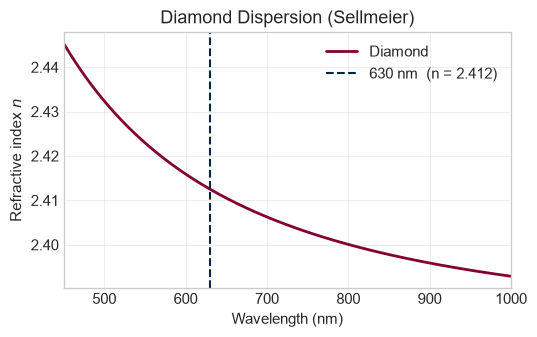

In [4]:
def n_diamond(wavelength_um):
    """
    Diamond refractive index via the two-term Sellmeier equation.

    Reference: Zaitsev, Optical Properties of Diamond (2001).
    Valid range: 0.23 – 5 µm.

    Parameters
    ----------
    wavelength_um : float  — free-space wavelength [µm]

    Returns
    -------
    float  — refractive index at the given wavelength
    """
    lam2 = np.asarray(wavelength_um, dtype=float) ** 2
    B1, C1 = 0.3306, 0.175**2  # first oscillator
    B2, C2 = 4.3356, 0.106**2  # second oscillator
    n2 = 1.0 + B1 * lam2 / (lam2 - C1) + B2 * lam2 / (lam2 - C2)
    return np.sqrt(n2)


# Tidy3D dispersive medium (Sellmeier coefficients)
diamond_medium = td.Sellmeier(coeffs=[(0.3306, 0.175**2), (4.3356, 0.106**2)])
air_medium = td.Medium(permittivity=1.0)

n_scout = float(n_diamond(SCOUT_WAVELENGTH_UM))
print(f"n_diamond at {SCOUT_WAVELENGTH_UM * 1e3:.0f} nm : {n_scout:.4f}")

# ── Dispersion curve ──────────────────────────────────────────────────────────
wl = np.linspace(0.45, 1.0, 400)
n_wl = n_diamond(wl)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(wl * 1e3, n_wl, color=RED, lw=2, label="Diamond")
ax.axvline(
    SCOUT_WAVELENGTH_UM * 1e3,
    color=BLUE,
    ls="--",
    lw=1.5,
    label=f"{SCOUT_WAVELENGTH_UM * 1e3:.0f} nm  (n = {n_scout:.3f})",
)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Refractive index $n$")
ax.set_title("Diamond Dispersion (Sellmeier)")
ax.legend(framealpha=0.85)
ax.set_xlim(450, 1000)
plt.tight_layout()
plt.show()

<a id='geometry'></a>
## 3. Generate Local Cavity Geometry

The notebook generates two local GDS files from embedded cavity and hole specifications:

- **`Cavity_Fab.gds`** — the diamond nanobeam outline written from the embedded cavity specification
- **`Holes_Fab.gds`** — the photonic crystal hole array written from the embedded hole positions and radii

The slab is extruded with the measured fabrication **sidewall angle of 15.6°**, producing a trapezoidal cross-section that models the etched nanobeam profile. The photonic-crystal holes are kept **vertical** through the slab, matching the geometry used in the shared simulation scripts.

> **Note:** All coordinates are in micrometres (µm); Tidy3D uses µm as its default length unit. The code cell below generates the local GDS files, stores them in a notebook-local runtime folder, and then builds the Tidy3D geometry from those files. The bundle `gds/` folder also contains `*_reference.gds` and `*_generated.gds` copies for direct comparison.


In [5]:
from typing import Dict, List, Optional, Tuple


def find_simulations_root() -> Path:
    """Locate a repo-style root when present, otherwise fall back to the notebook runtime root."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "gds").exists():
            return candidate
        if (candidate / "Simulations" / "gds").exists():
            return candidate / "Simulations"
    return RUNTIME_ROOT


class NotebookSimulationSetup:
    """Self-contained notebook copy of the shared simulation setup logic."""

    def __init__(
        self,
        thickness_um: float = 0.14,
        wavelength_um: float = 0.62,
        source_bandwidth_rel: float = 0.12,
        cavity_gds: Optional[str] = None,
        holes_gds: Optional[str] = None,
        sidewall_angle_deg: float = 0.0,
        trapezoid_slices: int = 1,
    ):
        self.thickness_um = thickness_um
        self.wavelength_um = wavelength_um
        self.source_bandwidth_rel = source_bandwidth_rel
        self._cavity_gds_input = cavity_gds
        self._holes_gds_input = holes_gds
        self.params = self._setup_geometry_parameters()
        self.sidewall_angle_deg = float(sidewall_angle_deg or 0.0)
        self.trapezoid_slices = int(trapezoid_slices or 1)
        self.diamond_medium, self.clad_medium, self.f0_center = (
            self._create_diamond_medium()
        )

    def _setup_geometry_parameters(self) -> Dict:
        print("=" * 70)
        print("SETTING UP GEOMETRY PARAMETERS")
        print("=" * 70)

        repo_root = find_simulations_root()

        if self._cavity_gds_input:
            cav_candidate = Path(self._cavity_gds_input)
            gds_path = (
                cav_candidate
                if cav_candidate.is_absolute()
                else (repo_root / "gds" / cav_candidate.name)
            )
            gds_path = gds_path.resolve()
        else:
            gds_path = (repo_root / "gds" / "Cavity_Design.gds").resolve()

        if self._holes_gds_input:
            hol_candidate = Path(self._holes_gds_input)
            hole_gds_path = (
                hol_candidate
                if hol_candidate.is_absolute()
                else (repo_root / "gds" / hol_candidate.name)
            )
            hole_gds_path = hole_gds_path.resolve()
        else:
            hole_gds_path = (repo_root / "gds" / "Holes_Design.gds").resolve()

        pad_x_neg = -5.0
        pad_x_pos = -5.0
        pad_y_neg = 2.0
        pad_y_pos = 2.0
        pad_z_neg = 2.0
        pad_z_pos = 2.0

        n_clad = 1.0
        chunk_max = 100
        top_cell_name = "TOP"
        hole_layer = (0, 0)

        print("✓ Geometry parameters loaded")
        print(f"  - Cavity thickness: {self.thickness_um} µm")
        print(f"  - Wavelength: {self.wavelength_um} µm")
        print(
            f"  - Optimized padding: x=[{pad_x_neg}, {pad_x_pos}], "
            f"y=[{pad_y_neg}, {pad_y_pos}], z=[{pad_z_neg}, {pad_z_pos}]"
        )

        return {
            "gds_path": gds_path,
            "hole_gds_path": hole_gds_path,
            "thickness_um": self.thickness_um,
            "wavelength_um": self.wavelength_um,
            "pad_x_neg": pad_x_neg,
            "pad_x_pos": pad_x_pos,
            "pad_y_neg": pad_y_neg,
            "pad_y_pos": pad_y_pos,
            "pad_z_neg": pad_z_neg,
            "pad_z_pos": pad_z_pos,
            "n_clad": n_clad,
            "chunk_max": chunk_max,
            "top_cell_name": top_cell_name,
            "hole_layer": hole_layer,
        }

    def _create_diamond_medium(self) -> Tuple[td.Medium, td.Medium, float]:
        print("\nCreating diamond medium with full Sellmeier dispersion...")

        def n_diamond_sellmeier(lambda_um: float) -> float:
            lam2 = float(lambda_um) ** 2
            B1, C1 = 0.3306, 0.175**2
            B2, C2 = 4.3356, 0.106**2
            n2 = 1.0 + B1 * lam2 / (lam2 - C1) + B2 * lam2 / (lam2 - C2)
            return float(np.sqrt(n2))

        n_diamond_ref = n_diamond_sellmeier(self.wavelength_um)

        print("  - Using full Sellmeier dispersion model")
        print("  - Coefficients: B1=0.3306, C1=0.175²; B2=4.3356, C2=0.106²")
        print(f"  - Reference n(λ={self.wavelength_um:.3f} µm) = {n_diamond_ref:.6f}")
        print("  - Full frequency-dependent dispersion enabled for FDTD simulation")

        sellmeier_coeffs = [
            (0.3306, 0.175**2),
            (4.3356, 0.106**2),
        ]

        diamond_medium = td.Sellmeier(coeffs=sellmeier_coeffs)
        clad_medium = td.Medium(permittivity=1.0)
        f0_center = C0 / (self.wavelength_um * 1e-6)
        return diamond_medium, clad_medium, f0_center

    @staticmethod
    def diamond_n_sellmeier(lambda_um: float) -> float:
        lam2 = float(lambda_um) ** 2
        B1, C1 = 0.3306, 0.175**2
        B2, C2 = 4.3356, 0.106**2
        n2 = 1.0 + B1 * lam2 / (lam2 - C1) + B2 * lam2 / (lam2 - C2)
        return float(np.sqrt(n2))

    def extract_geometry_from_gds(self) -> Dict:
        print(
            "\nGenerating local geometry from embedded cavity and hole specifications..."
        )

        lib = gdstk.read_gds(str(self.params["gds_path"]))
        gds_scale = lib.unit / 1e-6

        tops = lib.top_level()
        if not tops:
            raise RuntimeError("No top-level cells found in GDS.")
        top_cell = tops[0]

        print(f"  - Using cell: {top_cell.name}")

        bbox = top_cell.bounding_box()
        if bbox is None:
            raise RuntimeError("Could not determine bounding box.")

        xmin_orig, ymin_orig = np.array(bbox[0]) * gds_scale
        xmax_orig, ymax_orig = np.array(bbox[1]) * gds_scale

        print(
            f"  - Original bbox: x[{xmin_orig:.3f}, {xmax_orig:.3f}], y[{ymin_orig:.3f}, {ymax_orig:.3f}]"
        )

        xmin = xmin_orig
        xmax = xmax_orig
        ymin = ymin_orig
        ymax = ymax_orig

        left = xmin - self.params["pad_x_neg"]
        right = xmax + self.params["pad_x_pos"]
        bottom = ymin - self.params["pad_y_neg"]
        top = ymax + self.params["pad_y_pos"]
        down = -self.params["thickness_um"] / 2 - self.params["pad_z_neg"]
        up = self.params["thickness_um"] / 2 + self.params["pad_z_pos"]

        print(
            f"  - Geometry bbox: x[{xmin:.3f}, {xmax:.3f}], y[{ymin:.3f}, {ymax:.3f}]"
        )
        print(
            f"  - Simulation domain: left={left:.3f}, right={right:.3f}, bottom={bottom:.3f}, top={top:.3f}"
        )
        print(
            f"  - X truncation: {xmax_orig - xmin_orig:.3f} → {right - left:.3f} µm "
            f"(reduced by {xmax_orig - xmin_orig - (right - left):.3f} µm)"
        )

        size_x = right - left
        size_y = top - bottom
        size_z = up - down
        cx = (left + right) / 2
        cy = (bottom + top) / 2
        cz = 0.0

        print(f"  - Simulation size: ({size_x:.3f}, {size_y:.3f}, {size_z:.3f}) µm")
        print(f"  - Simulation center: ({cx:.3f}, {cy:.3f}, {cz:.3f}) µm")

        return {
            "xmin": xmin,
            "xmax": xmax,
            "ymin": ymin,
            "ymax": ymax,
            "size_x": size_x,
            "size_y": size_y,
            "size_z": size_z,
            "cx": cx,
            "cy": cy,
            "cz": cz,
        }

    def create_core_structure(self, geom_params: Dict) -> td.Structure:
        print("\nCreating core structure...")

        rect_vertices = [
            (geom_params["xmin"], geom_params["ymin"]),
            (geom_params["xmin"], geom_params["ymax"]),
            (geom_params["xmax"], geom_params["ymax"]),
            (geom_params["xmax"], geom_params["ymin"]),
        ]

        if self.sidewall_angle_deg <= 0.0:
            core_geo = td.PolySlab(
                vertices=rect_vertices,
                axis=2,
                slab_bounds=(
                    -self.params["thickness_um"] / 2,
                    self.params["thickness_um"] / 2,
                ),
                reference_plane="middle",
            )
            core_struct = td.Structure(geometry=core_geo, medium=self.diamond_medium)
            print(f"  - Core rectangle created with {len(rect_vertices)} vertices")
            print(f"  - Thickness: {self.params['thickness_um']} µm")
            return core_struct

        t = float(self.params["thickness_um"])
        angle_rad = float(np.deg2rad(self.sidewall_angle_deg))
        width_x = geom_params["xmax"] - geom_params["xmin"]
        width_y = geom_params["ymax"] - geom_params["ymin"]
        inset_top = t * np.tan(angle_rad)
        if 2 * inset_top >= min(width_x, width_y):
            print("⚠️  Sidewall angle too large for given footprint; reducing to fit.")
            max_inset = 0.49 * min(width_x, width_y)
            angle_rad = np.arctan(max_inset / t)
            inset_top = t * np.tan(angle_rad)

        core_geo = td.PolySlab(
            vertices=rect_vertices,
            axis=2,
            slab_bounds=(-t / 2, t / 2),
            reference_plane="bottom",
            sidewall_angle=angle_rad,
        )
        core_struct = td.Structure(geometry=core_geo, medium=self.diamond_medium)

        top_width_x = max(width_x - 2 * inset_top, 0.0)
        top_width_y = max(width_y - 2 * inset_top, 0.0)
        print(
            f"  - Trapezoidal core (native sidewall): sidewall_angle={self.sidewall_angle_deg:.2f}°"
        )
        print(f"  - Bottom width (x × y): {width_x:.3f} µm × {width_y:.3f} µm")
        print(f"  - Top width    (x × y): {top_width_x:.3f} µm × {top_width_y:.3f} µm")
        print(f"  - Thickness: {t} µm")
        return core_struct

    def create_hole_structures(self, geom_params: Dict) -> List[td.Structure]:
        print("\nCreating hole structures...")

        lib_holes = gdstk.read_gds(str(self.params["hole_gds_path"]))
        gds_scale_holes = lib_holes.unit / 1e-6

        tops_h = lib_holes.top_level()
        if not tops_h:
            raise RuntimeError("No top-level cells found in holes GDS.")
        hole_cell = tops_h[0]

        print(f"  - Using holes cell: {hole_cell.name}")

        holes_geo = td.Geometry.from_gds(
            gds_cell=hole_cell,
            gds_layer=self.params["hole_layer"][0],
            gds_dtype=self.params["hole_layer"][1],
            axis=2,
            slab_bounds=(
                -self.params["thickness_um"] / 2,
                self.params["thickness_um"] / 2,
            ),
            reference_plane="middle",
            gds_scale=gds_scale_holes,
        )

        holes_geoms = getattr(holes_geo, "geometries", [holes_geo])
        hole_structs = []

        for i in range(0, len(holes_geoms), self.params["chunk_max"]):
            chunk = holes_geoms[i : i + self.params["chunk_max"]]
            geom = td.GeometryGroup(geometries=chunk) if len(chunk) > 1 else chunk[0]
            hole_structs.append(td.Structure(geometry=geom, medium=self.clad_medium))

        print(f"  - Imported {len(holes_geoms)} hole polygon(s)")
        print(f"  - Created {len(hole_structs)} hole structure(s)")
        print(f"  - Thickness: {self.params['thickness_um']} µm")
        return hole_structs

    def create_sources_and_monitors(
        self, geom_params: Dict
    ) -> Tuple[td.PointDipole, List[td.Monitor]]:
        print("\nCreating sources and monitors...")

        source = td.PointDipole(
            center=(geom_params["cx"], geom_params["cy"], 0.0),
            source_time=td.GaussianPulse(
                freq0=self.f0_center,
                fwidth=self.f0_center * self.source_bandwidth_rel,
            ),
            polarization="Ey",
        )

        print(
            f"  - Source: Point dipole at ({geom_params['cx']:.3f}, {geom_params['cy']:.3f}, 0.0)"
        )
        print(f"  - Frequency: {self.f0_center / 1e12:.3f} THz")
        print(
            f"  - Bandwidth: {self.f0_center * self.source_bandwidth_rel / 1e12:.2f} THz"
        )

        monitors = []
        probe_monitor = td.FieldTimeMonitor(
            center=(geom_params["cx"], geom_params["cy"], 0.0),
            size=(0, 0, 0),
            name="probe",
            interval=5,
        )
        monitors.append(probe_monitor)

        flux_monitor = td.FluxMonitor(
            center=(geom_params["cx"], geom_params["cy"], 0.0),
            size=(geom_params["size_x"] * 0.8, geom_params["size_y"] * 0.8, 0),
            freqs=[self.f0_center],
            name="flux",
        )
        monitors.append(flux_monitor)

        field_monitor = td.FieldMonitor(
            center=(geom_params["cx"], geom_params["cy"], 0.0),
            size=(geom_params["size_x"] * 0.6, geom_params["size_y"] * 0.6, 0),
            freqs=[self.f0_center],
            name="field_near",
        )
        monitors.append(field_monitor)

        print(f"  - Created {len(monitors)} basic monitors")
        return source, monitors

    def create_minimal_q_probe(
        self, geom_params: Dict
    ) -> Tuple[td.PointDipole, List[td.Monitor]]:
        print("\nCreating minimal source and Q-probe monitor...")

        source = td.PointDipole(
            center=(geom_params["cx"], geom_params["cy"], 0.0),
            source_time=td.GaussianPulse(
                freq0=self.f0_center,
                fwidth=self.f0_center * self.source_bandwidth_rel,
            ),
            polarization="Ey",
        )

        probe_monitor = td.FieldTimeMonitor(
            center=(geom_params["cx"], geom_params["cy"], 0.0),
            size=(0, 0, 0),
            name="probe",
            interval=5,
        )

        print("  - Created minimal monitor set: ['probe']")
        return source, [probe_monitor]

    def create_farfield_monitors(self, geom_params: Dict) -> List[td.Monitor]:
        print("\nCreating improved far-field monitors...")

        monitor_z = 1.5
        monitor_size = 8.0
        print(f"  - Positioning monitors at z = {monitor_z} µm")
        print(f"  - Monitor size: {monitor_size} µm")

        monitors = []

        x_samples = np.linspace(-4, 4, 50)
        y_samples = np.linspace(-4, 4, 50)
        cartesian_monitor = td.FieldProjectionCartesianMonitor(
            center=(geom_params["cx"], geom_params["cy"], monitor_z),
            size=(monitor_size, monitor_size, 0.0),
            freqs=[self.f0_center],
            name="farfield_cartesian",
            x=x_samples,
            y=y_samples,
            proj_axis=2,
        )
        monitors.append(cartesian_monitor)

        u_max = 0.95
        ux_samples = np.linspace(-u_max, u_max, 40)
        uy_samples = np.linspace(-u_max, u_max, 40)
        kspace_monitor = td.FieldProjectionKSpaceMonitor(
            center=(geom_params["cx"], geom_params["cy"], monitor_z),
            size=(monitor_size, monitor_size, 0.0),
            freqs=[self.f0_center],
            name="farfield_kspace",
            ux=ux_samples,
            uy=uy_samples,
            proj_axis=2,
        )
        monitors.append(kspace_monitor)

        theta_deg = np.linspace(0.0, 90.0, 100)
        phi_deg = np.linspace(0.0, 360.0, 200)
        theta = np.deg2rad(theta_deg)
        phi = np.deg2rad(phi_deg)
        angle_monitor = td.FieldProjectionAngleMonitor(
            center=(geom_params["cx"], geom_params["cy"], monitor_z),
            size=(monitor_size, monitor_size, 0.0),
            freqs=[self.f0_center],
            name="farfield_angles",
            theta=theta,
            phi=phi,
            normal_dir="+",
        )
        monitors.append(angle_monitor)

        print(f"  - Created {len(monitors)} improved far-field monitors")
        return monitors

    def create_mode_volume_monitor(self, geom_params: Dict) -> td.Monitor:
        return td.FieldMonitor(
            name="fld_3d_box",
            center=(geom_params["cx"], geom_params["cy"], 0.0),
            size=(
                min(geom_params["size_x"], 6.0),
                min(geom_params["size_y"], 3.0),
                min(geom_params["size_z"], 2.0),
            ),
            fields=["Ex", "Ey", "Ez"],
            freqs=[self.f0_center],
            interval_space=(1, 1, 1),
        )

    def create_simulation(
        self, run_time_ps: float = 10.0, min_steps_per_wvl: int = 18
    ) -> td.Simulation:
        print("\nCreating complete simulation...")

        geom_params = self.extract_geometry_from_gds()
        core_struct = self.create_core_structure(geom_params)
        hole_structs = self.create_hole_structures(geom_params)
        all_structures = [core_struct] + hole_structs

        source, basic_monitors = self.create_sources_and_monitors(geom_params)
        farfield_monitors = self.create_farfield_monitors(geom_params)
        modevol_monitor = self.create_mode_volume_monitor(geom_params)
        all_monitors = basic_monitors + farfield_monitors + [modevol_monitor]

        run_time = run_time_ps * 1e-12
        simulation = td.Simulation(
            size=(geom_params["size_x"], geom_params["size_y"], geom_params["size_z"]),
            center=(geom_params["cx"], geom_params["cy"], geom_params["cz"]),
            grid_spec=td.GridSpec.auto(
                min_steps_per_wvl=min_steps_per_wvl, wavelength=self.wavelength_um
            ),
            structures=all_structures,
            sources=[source],
            monitors=all_monitors,
            run_time=run_time,
            boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        )

        print("✓ Complete simulation created successfully")
        print(f"  - Structures: {len(all_structures)}")
        print(f"  - Monitors: {len(all_monitors)}")
        print(f"  - Run time: {run_time_ps:.1f} ps")
        print(
            f"  - Grid: min_steps_per_wvl={min_steps_per_wvl} with wavelength={self.wavelength_um} µm"
        )
        print("  - Boundaries: PML(8 layers)")
        return simulation

    def create_q_scout_simulation(
        self, run_time_ps: float = 10.0, min_steps_per_wvl: int = 18
    ) -> td.Simulation:
        print("\nCreating minimal scout simulation (Q-only)...")

        geom_params = self.extract_geometry_from_gds()
        core_struct = self.create_core_structure(geom_params)
        hole_structs = self.create_hole_structures(geom_params)
        all_structures = [core_struct] + hole_structs

        source, probe_monitors = self.create_minimal_q_probe(geom_params)
        run_time = run_time_ps * 1e-12
        simulation = td.Simulation(
            size=(geom_params["size_x"], geom_params["size_y"], geom_params["size_z"]),
            center=(geom_params["cx"], geom_params["cy"], geom_params["cz"]),
            grid_spec=td.GridSpec.auto(
                min_steps_per_wvl=min_steps_per_wvl, wavelength=self.wavelength_um
            ),
            structures=all_structures,
            sources=[source],
            monitors=probe_monitors,
            run_time=run_time,
            boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        )

        print("✓ Minimal scout simulation created successfully")
        print(f"  - Structures: {len(all_structures)}")
        print(f"  - Monitors: {len(probe_monitors)} (probe only)")
        print(f"  - Run time: {run_time_ps:.1f} ps")
        print(
            f"  - Grid: min_steps_per_wvl={min_steps_per_wvl} with wavelength={self.wavelength_um} µm"
        )
        print("  - Boundaries: PML(8 layers)")
        return simulation


GEOMETRY_SETUP = NotebookSimulationSetup(
    thickness_um=THICKNESS_UM,
    wavelength_um=SCOUT_WAVELENGTH_UM,
    source_bandwidth_rel=SCOUT_BANDWIDTH,
    cavity_gds=CAVITY_GDS,
    holes_gds=HOLES_GDS,
    sidewall_angle_deg=SIDEWALL_ANGLE_DEG,
)

geom_params = GEOMETRY_SETUP.extract_geometry_from_gds()
core_structure = GEOMETRY_SETUP.create_core_structure(geom_params)
hole_structures = GEOMETRY_SETUP.create_hole_structures(geom_params)
structures = [core_structure] + hole_structures

X0, X1 = geom_params["xmin"], geom_params["xmax"]
Y0, Y1 = geom_params["ymin"], geom_params["ymax"]
CX, CY = geom_params["cx"], geom_params["cy"]

print(f"Cavity outline : x=[{X0:.3f}, {X1:.3f}] µm,  y=[{Y0:.3f}, {Y1:.3f}] µm")
print(f"Hole groups    : {len(hole_structures)} structure(s)")
print(f"Cavity centre  : ({CX:.4f}, {CY:.4f}) µm")

SETTING UP GEOMETRY PARAMETERS
✓ Geometry parameters loaded
  - Cavity thickness: 0.136 µm
  - Wavelength: 0.63 µm
  - Optimized padding: x=[-5.0, -5.0], y=[2.0, 2.0], z=[2.0, 2.0]

Creating diamond medium with full Sellmeier dispersion...
  - Using full Sellmeier dispersion model
  - Coefficients: B1=0.3306, C1=0.175²; B2=4.3356, C2=0.106²
  - Reference n(λ=0.630 µm) = 2.412500
  - Full frequency-dependent dispersion enabled for FDTD simulation

Generating local geometry from embedded cavity and hole specifications...
  - Using cell: TOP
  - Original bbox: x[-15.675, 15.675], y[-0.157, 0.157]
  - Geometry bbox: x[-15.675, 15.675], y[-0.157, 0.157]
  - Simulation domain: left=-10.675, right=10.675, bottom=-2.157, top=2.157
  - X truncation: 31.350 → 21.350 µm (reduced by 10.000 µm)
  - Simulation size: (21.350, 4.314, 4.136) µm
  - Simulation center: (0.000, 0.000, 0.000) µm

Creating core structure...
  - Trapezoidal core (native sidewall): sidewall_angle=15.60°
  - Bottom width (x × 

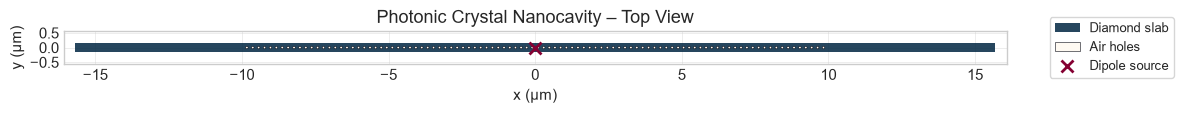

In [6]:
# ── Top-view geometry preview ─────────────────────────────────────────────────
lib_vis = gdstk.read_gds(str(HOLES_GDS))
scale_vis = lib_vis.unit / 1e-6
cell_vis = lib_vis.top_level()[0]

fig, ax = plt.subplots(figsize=(13.2, 4.8))

# Diamond slab background
rect = plt.Rectangle(
    (X0, Y0), X1 - X0, Y1 - Y0, fc=BLUE, ec="none", alpha=0.85, label="Diamond slab"
)
ax.add_patch(rect)

# Photonic crystal holes
for poly in cell_vis.polygons:
    if poly.layer == 0 and poly.datatype == 0:
        pts = poly.points * scale_vis
        patch = plt.Polygon(pts, closed=True, fc=WHITE, ec=BLACK, lw=0.4)
        ax.add_patch(patch)

# Dipole source position
ax.plot(CX, CY, "x", color=RED, ms=8, mew=2, label="Dipole source")

ax.set_xlim(X0 - 0.4, X1 + 0.4)
ax.set_ylim(Y0 - 0.4, Y1 + 0.4)
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Photonic Crystal Nanocavity – Top View")

legend_handles = [
    mpatches.Patch(fc=BLUE, ec="none", alpha=0.85, label="Diamond slab"),
    mpatches.Patch(fc=WHITE, ec=BLACK, lw=0.4, label="Air holes"),
    plt.Line2D(
        [0],
        [0],
        marker="x",
        color=RED,
        linestyle="None",
        markersize=8,
        markeredgewidth=2,
        label="Dipole source",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.80, 0.5),
    fontsize=9,
    frameon=True,
    borderaxespad=0.0,
)
fig.tight_layout(rect=(0, 0, 0.78, 1))
plt.show()

<a id='scout'></a>
## 4. Run a Broadband Resonance Search

A **y-polarized [point dipole](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PointDipole.html)** placed at the cavity centre drives a Gaussian pulse with a 12 % relative bandwidth, spanning ~580–700 nm. The only monitor is a zero-size **point probe** recording the time-domain field $E_y(t)$ throughout the simulation.

The simulation domain is enclosed by **[PML (perfectly matched layer)](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PML.html) boundaries** on all six sides to absorb outgoing radiation without reflections.

In [7]:
def print_simulation_summary(
    sim, stage_label, wavelength_nm, bandwidth_rel, output_note
):
    """Print a compact simulation summary without dumping the full object."""
    grid = sim.grid.num_cells
    total_cells = int(np.prod(grid))
    print(f"── {stage_label} ─────────────────────────────────────────────────")
    print(
        f"  Domain     : {sim.size[0]:.3f} × {sim.size[1]:.3f} × {sim.size[2]:.3f} µm"
    )
    print(f"  Grid cells : {grid[0]} × {grid[1]} × {grid[2]} = {total_cells:,}")
    print(f"  Run time   : {sim.run_time * 1e12:.1f} ps")
    print(
        f"  Excitation : Ey dipole @ {wavelength_nm:.1f} nm, Δf/f = {bandwidth_rel * 100:.1f}%"
    )
    print(f"  Outputs    : {output_note}")


sim_scout = GEOMETRY_SETUP.create_q_scout_simulation(
    run_time_ps=SCOUT_RUN_TIME_PS,
    min_steps_per_wvl=MIN_STEPS_PER_WVL,
)

print_simulation_summary(
    sim_scout,
    stage_label="Scout Simulation",
    wavelength_nm=SCOUT_WAVELENGTH_UM * 1e3,
    bandwidth_rel=SCOUT_BANDWIDTH,
    output_note="probe ringdown monitor",
)


Creating minimal scout simulation (Q-only)...

Generating local geometry from embedded cavity and hole specifications...
  - Using cell: TOP
  - Original bbox: x[-15.675, 15.675], y[-0.157, 0.157]
  - Geometry bbox: x[-15.675, 15.675], y[-0.157, 0.157]
  - Simulation domain: left=-10.675, right=10.675, bottom=-2.157, top=2.157
  - X truncation: 31.350 → 21.350 µm (reduced by 10.000 µm)
  - Simulation size: (21.350, 4.314, 4.136) µm
  - Simulation center: (0.000, 0.000, 0.000) µm

Creating core structure...
  - Trapezoidal core (native sidewall): sidewall_angle=15.60°
  - Bottom width (x × y): 31.350 µm × 0.314 µm
  - Top width    (x × y): 31.274 µm × 0.238 µm
  - Thickness: 0.136 µm

Creating hole structures...
  - Using holes cell: TOP
  - Imported 100 hole polygon(s)
  - Created 1 hole structure(s)
  - Thickness: 0.136 µm

Creating minimal source and Q-probe monitor...
  - Created minimal monitor set: ['probe']
✓ Minimal scout simulation created successfully
  - Structures: 2
  - Mo

In [8]:
if RUN_SIMULATIONS:
    import tidy3d.web as web

    data_scout = web.run(
        sim_scout,
        task_name=SCOUT_TASK_NAME,
        path=str(SCOUT_RUN_RESULTS),
    )
    print(f"Scout simulation complete: {SCOUT_RUN_RESULTS.name}")
else:
    print(f"Loaded scout cache: {SCOUT_LOAD_RESULTS.name}")
    data_scout = td.SimulationData.from_file(str(SCOUT_LOAD_RESULTS))
    print("  Probe time trace ready for resonance extraction.")

16:33:19 W. Europe Daylight Time INFO: Simulation cache hit for workflow 'FDTD';
                                 using local results.

                                 Loading simulation from local cache. View      
                                 cached task using web UI at                    
                                 ]8;id=3810954;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5ed20813-c687-4a40-abbd-e2e4e39a9192\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=3810955;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5ed20813-c687-4a40-abbd-e2e4e39a9192\task]8;;\
                                 ]8;id=3810955;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5ed20813-c687-4a40-abbd-e2e4e39a9192\Id]8;;\]8;id=3810954;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5ed20813-c687-4a40-abbd-e2e4e39a9192\=]8;;\]8;id=3810956;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5ed20813-c687-4a40-abbd-e2e4e39a9192\fdve]8;;\]8;id=3810954;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5ed20813-c687-4a40-abbd-e2e4e39a9192\-5ed20813-c687-4a40-abbd-e2e4e39a9192']8;;\.

                                 WARNING: Simulation final field decay value of 
                                 0.141 is greater than the simulation shutoff   
                                 threshold of 1e-05. Consider running the       
                                 simulation again with a larger 'run_time'      
                                 duration for more accurate results.            

Scout simulation complete: results_scout_analysis_full_0.136um.hdf5


<a id='qfactor'></a>
## 5. Extract the Cavity Q-Factor

The Tidy3D **[`ResonanceFinder`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.resonance.ResonanceFinder.html)** plugin decomposes the time-domain ringdown $E_y(t)$ into a sum of decaying sinusoids using a matrix-pencil (Prony) method:

$$E_y(t) \approx \sum_k A_k \, e^{-(\omega_k / 2Q_k)\,t} \cos(\omega_k t + \phi_k)$$

Each mode is characterized by its frequency $\omega_k$ and quality factor $Q_k = \omega_k \tau_k / 2$, where $\tau_k$ is the energy decay time.

-- Q-factor extraction --


16:33:26 W. Europe Daylight Time INFO:   Running ResonanceFinder (nfreqs = 400)

16:33:27 W. Europe Daylight Time INFO:   Completed ResonanceFinder (nfreqs = 13)

  Resonance wavelength : 639.196 nm
  Quality factor  Q    : 68990
  Energy decay time tau  : 46.82 ps


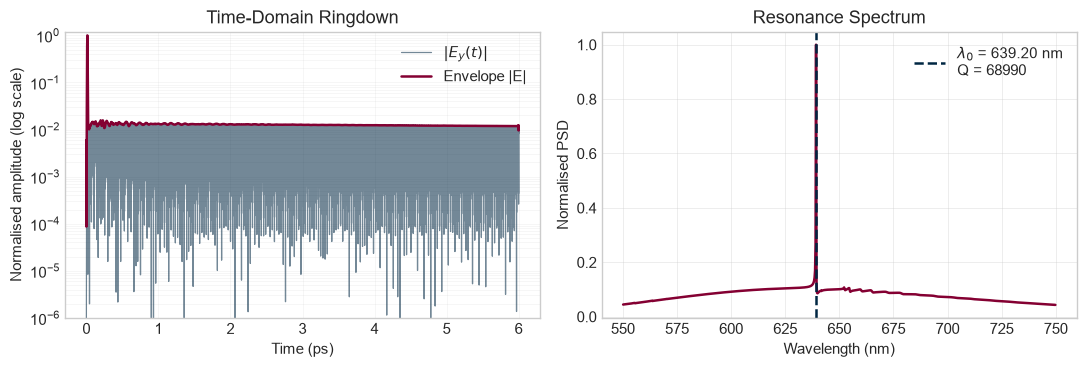

In [9]:
def extract_resonance(
    data_scout,
    monitor_name="probe",
    wavelength_centre_um=None,
    bandwidth_rel=None,
    q_min=1e3,
    q_max=1e6,
    init_num_freqs=400,
    rcond=1e-5,
):
    """
    Extract the dominant cavity resonance from the scout ringdown.

    Uses the Tidy3D ResonanceFinder (matrix-pencil / Prony method) via
    run_raw_signal() on the Ey time trace.  freq_window is computed
    automatically from the broadband source parameters.

    Parameters
    ----------
    data_scout : td.SimulationData
    monitor_name : str
    wavelength_centre_um : float  -- source centre wavelength [um]; defaults to SCOUT_WAVELENGTH_UM
    bandwidth_rel : float  -- relative bandwidth; defaults to SCOUT_BANDWIDTH
    q_min, q_max : float  -- Q-factor acceptance window
    init_num_freqs, rcond : ResonanceFinder hyper-parameters

    Returns
    -------
    dict with keys: freq_Hz, wavelength_um, Q, decay_time_ps, amplitude
    """
    if wavelength_centre_um is None:
        wavelength_centre_um = SCOUT_WAVELENGTH_UM
    if bandwidth_rel is None:
        bandwidth_rel = SCOUT_BANDWIDTH

    mon = data_scout[monitor_name]
    ey = mon.Ey.values.squeeze().astype(complex)
    t = mon.Ey.coords["t"].values
    dt = float(t[1] - t[0])  # time step [s]

    # Frequency search window: source centre +/- 1 bandwidth
    f0 = C0 / (wavelength_centre_um * 1e-6)
    fwidth = f0 * bandwidth_rel
    freq_window = (f0 - fwidth, f0 + fwidth)

    rf = ResonanceFinder(
        freq_window=freq_window,
        init_num_freqs=init_num_freqs,
        rcond=rcond,
    )
    # run_raw_signal takes a complex 1-D signal and the time step
    res = rf.run_raw_signal(signal=ey, time_step=dt)
    df = (
        res.to_dataframe()
    )  # index = freq [Hz]; cols: decay, Q, amplitude, phase, error

    df = df[(df.index > 0) & (df["Q"] > q_min) & (df["Q"] < q_max)]
    df = df.sort_values("amplitude", ascending=False)

    if df.empty:
        tail_amp = float(np.abs(ey[-1]))
        peak_amp = float(np.max(np.abs(ey)))
        if peak_amp > 0 and tail_amp / peak_amp > 1e-3:
            raise RuntimeError(
                "ResonanceFinder found no valid modes because the scout "
                "signal has not decayed by the end of the run. "
                "The loaded scout result is likely unstable or too short; "
                "use a clean cache or rerun Stage 1 with a longer runtime."
            )
        raise RuntimeError(
            "ResonanceFinder found no valid modes. "
            "Try adjusting q_min or the simulation bandwidth."
        )

    freq = float(df.index[0])
    Q = float(df["Q"].iloc[0])
    tau_ps = Q / (np.pi * freq) * 1e12
    wl_um = (C0 / freq) * 1e6

    return {
        "freq_Hz": freq,
        "wavelength_um": wl_um,
        "Q": Q,
        "decay_time_ps": tau_ps,
        "amplitude": float(df["amplitude"].iloc[0]),
    }


print("-- Q-factor extraction --")
q_results = extract_resonance(data_scout)
wavelength_lockin = q_results["wavelength_um"]
print(f"  Resonance wavelength : {wavelength_lockin * 1e3:.3f} nm")
print(f"  Quality factor  Q    : {q_results['Q']:.0f}")
print(f"  Energy decay time tau  : {q_results['decay_time_ps']:.2f} ps")

# -- Ringdown visualisation
probe = data_scout["probe"]
ey = probe.Ey.values.squeeze()
t = probe.Ey.coords["t"].values * 1e12
env = np.abs(hilbert(ey))

dt = np.diff(t[:2])[0] * 1e-12
freqs_fft = np.fft.rfftfreq(len(ey), d=dt)
spec = np.abs(np.fft.rfft(ey))
wl_spec = np.where(freqs_fft[1:] > 0, C0 / freqs_fft[1:] * 1e9, np.nan)
mask = (wl_spec > 550) & (wl_spec < 750)
wl_plot = wl_spec[mask] if np.any(mask) else wl_spec
spec_plot = spec[1:][mask] if np.any(mask) else spec[1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

signal_abs = np.abs(ey) / np.max(np.abs(ey))
env_n = env / env.max()
ringdown_floor = 1e-6

ax1.semilogy(
    t,
    np.clip(signal_abs, ringdown_floor, None),
    color=BLUE,
    lw=0.9,
    alpha=0.55,
    label="$|E_y(t)|$",
)
ax1.semilogy(
    t, np.clip(env_n, ringdown_floor, None), color=RED, lw=1.8, label="Envelope |E|"
)
ax1.set_xlabel("Time (ps)")
ax1.set_ylabel("Normalised amplitude (log scale)")
ax1.set_title("Time-Domain Ringdown")
ax1.set_ylim(ringdown_floor, 1.2)
ax1.grid(True, which="both", alpha=0.25)
ax1.legend()

ax2.plot(wl_plot, spec_plot / spec_plot.max(), color=RED, lw=1.8)
ax2.axvline(
    wavelength_lockin * 1e3,
    color=BLUE,
    ls="--",
    lw=1.8,
    label=f"$\\lambda_0$ = {wavelength_lockin * 1e3:.2f} nm\nQ = {q_results['Q']:.0f}",
)
ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel("Normalised PSD")
ax2.set_title("Resonance Spectrum")
ax2.legend()

plt.tight_layout()
plt.show()

<a id='lockin'></a>
## 6. Run a Narrowband Characterization Simulation

The lock-in stage uses the resonance wavelength detected in Stage 1 as its centre frequency with a narrow 2 % bandwidth. This minimizes spectral leakage and maximizes the steady-state field amplitude at the resonance. The monitor suite below follows the same configuration used in the shared simulation scripts and includes seven monitors:

| Monitor | Type | Purpose |
|---------|------|----------|
| `probe` | [`FieldTimeMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldTimeMonitor.html) | Q verification from ringdown |
| `flux` | [`FluxMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FluxMonitor.html) | In-plane flux check at the cavity plane |
| `field_near` | [`FieldMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html) (2-D, z = 0) | Near-field mode profile |
| `farfield_cartesian` | [`FieldProjectionCartesianMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldProjectionCartesianMonitor.html) | Cartesian projected far field |
| `farfield_kspace` | [`FieldProjectionKSpaceMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldProjectionKSpaceMonitor.html) | k-space back-focal-plane map |
| `farfield_angles` | [`FieldProjectionAngleMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldProjectionAngleMonitor.html) | Angular radiation pattern |
| `fld_3d_box` | [`FieldMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html) (3-D volume) | Mode volume integration |

In [10]:
LOCKIN_SETUP = NotebookSimulationSetup(
    thickness_um=THICKNESS_UM,
    wavelength_um=wavelength_lockin,
    source_bandwidth_rel=LOCKIN_BANDWIDTH,
    cavity_gds=CAVITY_GDS,
    holes_gds=HOLES_GDS,
    sidewall_angle_deg=SIDEWALL_ANGLE_DEG,
)

sim_lockin = LOCKIN_SETUP.create_simulation(
    run_time_ps=LOCKIN_RUN_TIME_PS,
    min_steps_per_wvl=MIN_STEPS_PER_WVL,
)

print_simulation_summary(
    sim_lockin,
    stage_label="Lock-in Simulation",
    wavelength_nm=wavelength_lockin * 1e3,
    bandwidth_rel=LOCKIN_BANDWIDTH,
    output_note="probe, flux, near field, 3-D box, cartesian and angular far-field projections",
)

SETTING UP GEOMETRY PARAMETERS
✓ Geometry parameters loaded
  - Cavity thickness: 0.136 µm
  - Wavelength: 0.6391957274013039 µm
  - Optimized padding: x=[-5.0, -5.0], y=[2.0, 2.0], z=[2.0, 2.0]

Creating diamond medium with full Sellmeier dispersion...
  - Using full Sellmeier dispersion model
  - Coefficients: B1=0.3306, C1=0.175²; B2=4.3356, C2=0.106²
  - Reference n(λ=0.639 µm) = 2.411554
  - Full frequency-dependent dispersion enabled for FDTD simulation

Creating complete simulation...

Generating local geometry from embedded cavity and hole specifications...
  - Using cell: TOP
  - Original bbox: x[-15.675, 15.675], y[-0.157, 0.157]
  - Geometry bbox: x[-15.675, 15.675], y[-0.157, 0.157]
  - Simulation domain: left=-10.675, right=10.675, bottom=-2.157, top=2.157
  - X truncation: 31.350 → 21.350 µm (reduced by 10.000 µm)
  - Simulation size: (21.350, 4.314, 4.136) µm
  - Simulation center: (0.000, 0.000, 0.000) µm

Creating core structure...
  - Trapezoidal core (native sidewall

In [11]:
if RUN_SIMULATIONS and RUN_LOCKIN_STAGE:
    import tidy3d.web as web

    data = web.run(
        sim_lockin,
        task_name=LOCKIN_TASK_NAME,
        path=str(LOCKIN_RUN_RESULTS),
    )
    print(f"Lock-in simulation complete: {LOCKIN_RUN_RESULTS.name}")
else:
    if RUN_SIMULATIONS and not RUN_LOCKIN_STAGE:
        print(
            f"{SIMULATION_PROFILE} selected: skipping Stage 2 rerun and "
            f"reusing {LOCKIN_LOAD_RESULTS.name}."
        )
    else:
        print(f"Loaded lock-in cache: {LOCKIN_LOAD_RESULTS.name}")
    data = td.SimulationData.from_file(str(LOCKIN_LOAD_RESULTS))
    print(f"  Monitor suite ready: {len(data.monitor_data)} datasets loaded.")

16:33:28 W. Europe Daylight Time INFO: Simulation cache hit for workflow 'FDTD';
                                 using local results.

                                 Loading simulation from local cache. View      
                                 cached task using web UI at                    
                                 ]8;id=3810960;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f596a84-418a-4079-b230-4ba7bc37583d\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=3810961;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f596a84-418a-4079-b230-4ba7bc37583d\task]8;;\
                                 ]8;id=3810961;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f596a84-418a-4079-b230-4ba7bc37583d\Id]8;;\]8;id=3810960;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f596a84-418a-4079-b230-4ba7bc37583d\=]8;;\]8;id=3810962;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f596a84-418a-4079-b230-4ba7bc37583d\fdve]8;;\]8;id=3810960;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f596a84-418a-4079-b230-4ba7bc37583d\-9f596a84-418a-4079-b230-4ba7bc37583d']8;;\.

                                 WARNING: Simulation final field decay value of 
                                 0.117 is greater than the simulation shutoff   
                                 threshold of 1e-05. Consider running the       
                                 simulation again with a larger 'run_time'      
                                 duration for more accurate results.            

Lock-in simulation complete: results_lockin_analysis_full_0.136um.hdf5


<a id='nearfield'></a>
## 7. Near-Field Mode Analysis

The `field_near` monitor records the electric field components $E_x, E_y, E_z$ on a 2-D cross-section at $z = 0$ (mid-plane of the slab). We visualize the total intensity $|\mathbf{E}|^2 = |E_x|^2 + |E_y|^2 + |E_z|^2$, overlay the notebook-generated cavity outline, and characterize the lateral confinement by fitting 1-D Gaussian profiles.

The **effective mode area** is defined as:

$$A_{\text{eff}} = \frac{\left(\iint I \, dA\right)^2}{\iint I^2 \, dA}$$

── Near-field analysis ──────────────────────────────────────────────────


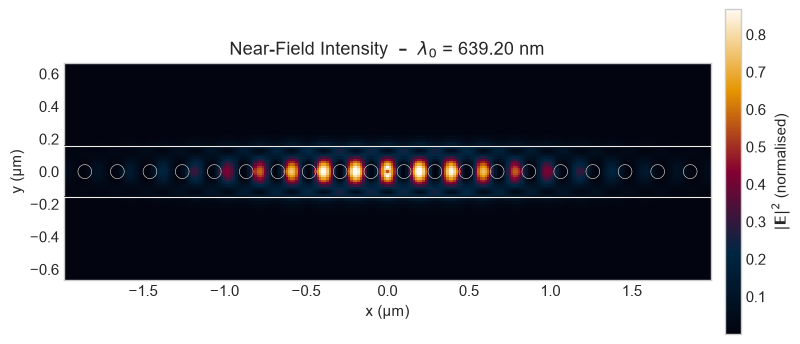

  1/e² width  w_x   = 1545 nm  (FWHM = 3638 nm)
  1/e² width  w_y   = 198 nm  (FWHM = 466 nm)
  Eff. mode area    = 1.6649 µm²  = 4.075 λ²


In [12]:
def _coords_to_um(arr):
    """Auto-convert coordinate array from metres to µm if needed."""
    return arr * 1e6 if np.max(np.abs(arr)) < 1e-3 else arr


def extract_nearfield_intensity(data, monitor_name="field_near"):
    """Return 2-D intensity map and coordinate arrays (in µm)."""
    mon = data[monitor_name]
    Ex = mon.Ex.isel(f=0).values.squeeze()
    Ey = mon.Ey.isel(f=0).values.squeeze()
    Ez = mon.Ez.isel(f=0).values.squeeze() if "Ez" in mon else 0.0
    I = np.abs(Ex) ** 2 + np.abs(Ey) ** 2 + np.abs(Ez) ** 2
    x = _coords_to_um(mon.Ey.coords["x"].values)
    y = _coords_to_um(mon.Ey.coords["y"].values)
    # Ensure I has shape (ny, nx) to match pcolormesh convention
    if I.shape == (len(x), len(y)):
        I = I.T
    return I, x, y


def crop_field(I, x, y, x_lim=(-2.0, 2.0), y_lim=(-0.7, 0.7)):
    """Crop a 2-D intensity map to the specified window (µm)."""
    xi = (x >= x_lim[0]) & (x <= x_lim[1])
    yi = (y >= y_lim[0]) & (y <= y_lim[1])
    return I[np.ix_(yi, xi)], x[xi], y[yi]


def overlay_gds_outline(ax, x_window, y_window, holes_gds=HOLES_GDS):
    """Overlay the notebook-generated cavity outline on top of the near-field map."""
    rect_kw_outer = dict(fill=False, ec=BLACK, lw=1.4, alpha=0.55, zorder=4)
    rect_kw_inner = dict(fill=False, ec=WHITE, lw=0.8, alpha=0.95, zorder=5)
    ax.add_patch(plt.Rectangle((X0, Y0), X1 - X0, Y1 - Y0, **rect_kw_outer))
    ax.add_patch(plt.Rectangle((X0, Y0), X1 - X0, Y1 - Y0, **rect_kw_inner))

    lib = gdstk.read_gds(str(holes_gds))
    scale = lib.unit / 1e-6
    cell = lib.top_level()[0]

    for poly in cell.polygons:
        if poly.layer != 0 or poly.datatype != 0:
            continue
        pts = poly.points * scale
        if (
            pts[:, 0].max() < x_window[0]
            or pts[:, 0].min() > x_window[1]
            or pts[:, 1].max() < y_window[0]
            or pts[:, 1].min() > y_window[1]
        ):
            continue
        ax.add_patch(
            plt.Polygon(
                pts,
                closed=True,
                fill=False,
                ec=BLACK,
                lw=1.0,
                alpha=0.5,
                zorder=4,
                joinstyle="round",
            )
        )
        ax.add_patch(
            plt.Polygon(
                pts,
                closed=True,
                fill=False,
                ec=WHITE,
                lw=0.4,
                alpha=0.95,
                zorder=5,
                joinstyle="round",
            )
        )


def plot_nearfield(I, x, y, wavelength_nm, cmap=None):
    """Display the near-field intensity map."""
    cmap = cmap or mono_cmap
    I_n = I / I.max()
    vmin, vmax = np.percentile(I_n, [0.1, 99.9])

    fig, ax = plt.subplots(figsize=(8.2, 3.6))
    im = ax.pcolormesh(x, y, I_n, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    overlay_gds_outline(ax, (x.min(), x.max()), (y.min(), y.max()))
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("$|\\mathbf{E}|^2$ (normalised)")
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"Near-Field Intensity  –  $\\lambda_0$ = {wavelength_nm:.2f} nm")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


def gaussian_1d(x, A, x0, sigma, bg):
    return A * np.exp(-2 * (x - x0) ** 2 / sigma**2) + bg


def compute_confinement(I, x, y, wavelength_um):
    """
    Quantify the lateral confinement from 1-D Gaussian fits.

    Returns a dict with 1/e² widths, FWHM, effective area, and
    effective area normalised to λ².
    """
    results = {}
    for axis_label, coords, profile in [
        ("x", x, I.sum(axis=0)),
        ("y", y, I.sum(axis=1)),
    ]:
        pn = profile / profile.max()
        try:
            p0 = [1.0, coords[np.argmax(pn)], 0.25, 0.0]
            popt, _ = curve_fit(gaussian_1d, coords, pn, p0=p0, maxfev=8000)
            w = abs(popt[2])  # 1/e² half-width
        except RuntimeError:
            above = coords[pn > np.exp(-2)]
            w = (above[-1] - above[0]) / 2 if len(above) > 1 else np.nan
        results[f"w_{axis_label}_um"] = w
        results[f"fwhm_{axis_label}_nm"] = 2 * np.sqrt(2 * np.log(2)) * w * 1e3

    dx = abs(np.diff(x[:2])[0])
    dy = abs(np.diff(y[:2])[0])
    A_eff = float(np.sum(I) ** 2 / np.sum(I**2) * dx * dy)
    results["A_eff_um2"] = A_eff
    results["A_eff_lambda2"] = A_eff / wavelength_um**2
    return results


# ── Run analysis ──────────────────────────────────────────────────────────────
print("── Near-field analysis ──────────────────────────────────────────────────")

I_raw, x_raw, y_raw = extract_nearfield_intensity(data)
I_nf, x_nf, y_nf = crop_field(I_raw, x_raw, y_raw)
plot_nearfield(I_nf, x_nf, y_nf, wavelength_lockin * 1e3)

conf = compute_confinement(I_nf, x_nf, y_nf, wavelength_lockin)
print(
    f"  1/e² width  w_x   = {conf['w_x_um'] * 1e3:.0f} nm"
    f"  (FWHM = {conf['fwhm_x_nm']:.0f} nm)"
)
print(
    f"  1/e² width  w_y   = {conf['w_y_um'] * 1e3:.0f} nm"
    f"  (FWHM = {conf['fwhm_y_nm']:.0f} nm)"
)
print(
    f"  Eff. mode area    = {conf['A_eff_um2']:.4f} µm²"
    f"  = {conf['A_eff_lambda2']:.3f} λ²"
)

<a id='modevolume'></a>
## 8. Mode Volume and Purcell Enhancement

The **effective mode volume** is computed from the 3-D field distribution stored in `fld_3d_box`:

$$V_{\text{eff}} = \frac{\int \varepsilon(\mathbf{r})\,|\mathbf{E}(\mathbf{r})|^2 \, d^3r}{\max\!\left[\varepsilon(\mathbf{r})\,|\mathbf{E}(\mathbf{r})|^2\right]}$$

The permittivity $\varepsilon(\mathbf{r})$ is taken as $n_{\text{diamond}}^2$ inside the slab and 1 (air) outside.  The Purcell factor follows directly from $Q$ and $V_{\text{eff}}$.

In [13]:
def compute_mode_volume(
    data, monitor_name="fld_3d_box", wavelength_um=0.62, thickness_um=0.136
):
    """
    Compute the effective mode volume V_eff and its normalisation (λ/2n)³.

    The permittivity is estimated analytically: n_diamond² inside the slab
    (|z| < thickness_um/2) and 1 elsewhere.

    Parameters
    ----------
    data : td.SimulationData
    monitor_name : str
    wavelength_um : float  — resonance wavelength [µm]
    thickness_um : float   — slab thickness [µm]

    Returns
    -------
    V_eff_um3 : float  — effective mode volume [µm³]
    V_norm    : float  — V_eff / (λ/2n)³  (dimensionless)
    """
    mon = data[monitor_name]
    Ex = mon.Ex.isel(f=0).values.squeeze()
    Ey = mon.Ey.isel(f=0).values.squeeze()
    Ez = mon.Ez.isel(f=0).values.squeeze() if "Ez" in mon else np.zeros_like(Ex)

    x = _coords_to_um(mon.Ex.coords["x"].values)
    y = _coords_to_um(mon.Ex.coords["y"].values)
    z = _coords_to_um(mon.Ex.coords["z"].values)

    # Ensure field shape (nz, ny, nx)
    I = np.abs(Ex) ** 2 + np.abs(Ey) ** 2 + np.abs(Ez) ** 2
    if I.shape == (len(x), len(y), len(z)):
        I = np.transpose(I, (2, 1, 0))

    # Permittivity map
    n = float(n_diamond(wavelength_um))
    Z3d = z[:, None, None] * np.ones_like(I)
    eps = np.where(np.abs(Z3d) < thickness_um / 2, n**2, 1.0)

    eps_I = eps * I
    dV = abs(np.diff(x[:2])[0]) * abs(np.diff(y[:2])[0]) * abs(np.diff(z[:2])[0])
    V_eff = float(np.sum(eps_I) * dV / np.max(eps_I))

    lambda_n = wavelength_um / n
    V_norm = V_eff / (lambda_n / 2) ** 3
    return V_eff, V_norm


def compute_purcell(Q, V_eff_um3, wavelength_um):
    """
    Purcell enhancement factor  F_P = (3/4π²) (λ/n)³ Q / V_eff.

    Parameters
    ----------
    Q : float  — quality factor
    V_eff_um3 : float  — effective mode volume [µm³]
    wavelength_um : float  — resonance wavelength [µm]

    Returns
    -------
    float  — Purcell factor
    """
    n = float(n_diamond(wavelength_um))
    lam_n3 = (wavelength_um / n) ** 3  # (λ/n)³ [µm³]
    return float((3.0 / (4.0 * np.pi**2)) * lam_n3 / V_eff_um3 * Q)


print("── Mode volume and Purcell factor ───────────────────────────────────────")
V_eff, V_norm = compute_mode_volume(
    data, wavelength_um=wavelength_lockin, thickness_um=THICKNESS_UM
)
Q_val = q_results["Q"]
F_P = compute_purcell(Q_val, V_eff, wavelength_lockin)

print(f"  Effective mode volume  V_eff  = {V_eff:.4f} µm³")
print(f"                                = {V_norm:.3f} × (λ/2n)³")
print(f"  Quality factor         Q      = {Q_val:.0f}")
print(f"  Purcell factor         F_P    = {F_P:.1f}")

── Mode volume and Purcell factor ───────────────────────────────────────
  Effective mode volume  V_eff  = 0.1556 µm³
                                = 66.854 × (λ/2n)³
  Quality factor         Q      = 68990
  Purcell factor         F_P    = 627.3


<a id='farfield'></a>
## 9. Far-Field Radiation Pattern and Collection Efficiency

The [`FieldProjectionKSpaceMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldProjectionKSpaceMonitor.html) projects the fields onto a plane at height $z_{\text{ff}}$ and records the complex amplitudes as a function of normalized wavevectors $(u_x, u_y) = (k_x/k_0, k_y/k_0)$. A circle of radius NA in this plane corresponds to the acceptance cone of an objective lens.

In this notebook, collection efficiency is reported relative to the **total emission into both hemispheres**. Since the monitor samples one projected hemisphere, the monitored hemispheric power is multiplied by 2 in the denominator:

$$\eta_{\text{NA}} = \frac{\displaystyle\iint_{u_x^2 + u_y^2 \leq \text{NA}^2} I(u_x, u_y)\, du_x\, du_y}{\displaystyle 2\iint_{u_x^2 + u_y^2 \leq 1} I(u_x, u_y)\, du_x\, du_y}$$

── Far-field radiation pattern ──────────────────────────────────────────
  Collection efficiency at NA = 0.65: 31.2%


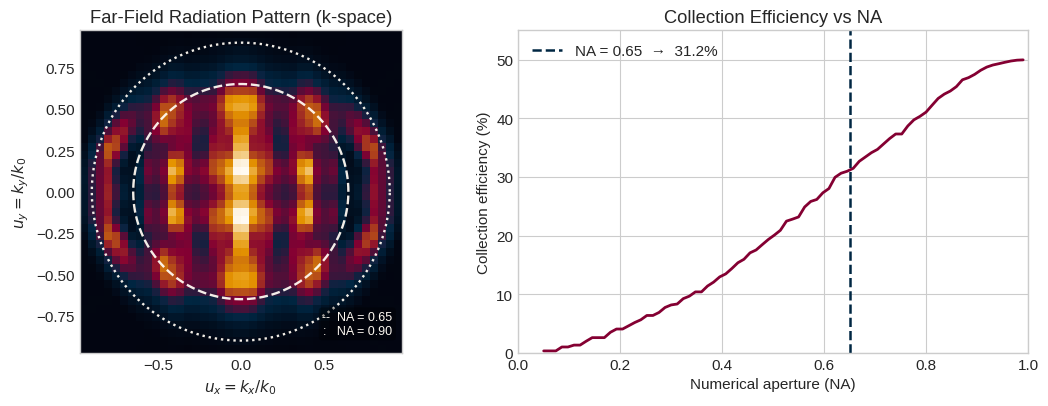

In [14]:
def extract_kspace_intensity(data, monitor_name="farfield_kspace"):
    """Return far-field intensity on the (ux, uy) k-space grid."""
    mon = data[monitor_name]
    # Get field projections – try Etheta/Ephi first, fall back to Ex/Ey
    if hasattr(mon, "Etheta"):
        dims = mon.Etheta.dims
        if "r" in dims:
            Et = mon.Etheta.isel(f=0, r=0).values.squeeze()
            Ep = mon.Ephi.isel(f=0, r=0).values.squeeze()
        else:
            Et = mon.Etheta.isel(f=0).values.squeeze()
            Ep = mon.Ephi.isel(f=0).values.squeeze()
    else:
        Et = mon.Ex.isel(f=0).values.squeeze()
        Ep = mon.Ey.isel(f=0).values.squeeze()
    I = np.abs(Et) ** 2 + np.abs(Ep) ** 2
    ux = np.asarray(mon.ux)
    uy = np.asarray(mon.uy)
    return I, ux, uy


def collection_efficiency(I, ux, uy, na, n_bg=1.0):
    """
    Fraction of total emitted power collected within NA.

    Parameters
    ----------
    I : 2-D array  — intensity on (ux, uy) grid  (shape: n_ux × n_uy)
    ux, uy : 1-D arrays
    na, n_bg : float

    Returns
    -------
    float  — collection efficiency [0, 1]
    """
    UX, UY = np.meshgrid(ux, uy, indexing="ij")
    R2 = UX**2 + UY**2
    inside_na = R2 <= (na / n_bg) ** 2
    inside_all = R2 <= 1.0
    upper_total = np.sum(I[inside_all])
    if upper_total == 0:
        return 0.0
    total_emitted = 2.0 * upper_total
    return float(np.sum(I[inside_na]) / total_emitted)


# ── Compute and plot ───────────────────────────────────────────────────────────
print("── Far-field radiation pattern ──────────────────────────────────────────")

I_ff, ux, uy = extract_kspace_intensity(data)
eta_NA = collection_efficiency(I_ff, ux, uy, NA, N_BG)
print(f"  Collection efficiency at NA = {NA}: {eta_NA * 100:.1f}%")

# NA sweep
na_sweep = np.linspace(0.05, 0.99, 80)
eta_sweep = [collection_efficiency(I_ff, ux, uy, na_) for na_ in na_sweep]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.2))

# k-space map
UX_g, UY_g = np.meshgrid(ux, uy, indexing="ij")
ax1.pcolormesh(
    ux, uy, I_ff.T / I_ff.max(), cmap=mono_cmap, vmin=0, vmax=1, shading="auto"
)
theta_c = np.linspace(0, 2 * np.pi, 300)
for na_c, ls_c, lbl_c in [(NA, "--", f"NA = {NA:.2f}"), (0.9, ":", "NA = 0.90")]:
    if na_c <= 1.0:
        ax1.plot(
            na_c * np.cos(theta_c),
            na_c * np.sin(theta_c),
            color=WHITE,
            lw=1.7,
            ls=ls_c,
            alpha=0.95,
        )
ax1.set_aspect("equal")
ax1.set_xlabel("$u_x = k_x/k_0$")
ax1.set_ylabel("$u_y = k_y/k_0$")
ax1.set_title("Far-Field Radiation Pattern (k-space)")
ax1.text(
    0.97,
    0.05,
    f"--  NA = {NA:.2f}\n:   NA = 0.90",
    transform=ax1.transAxes,
    ha="right",
    va="bottom",
    color=WHITE,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.28", fc=(0, 0, 0, 0.35), ec="none"),
)

# Collection efficiency curve
ax2.plot(na_sweep, np.array(eta_sweep) * 100, color=RED, lw=2)
ax2.axvline(NA, color=BLUE, ls="--", lw=1.8, label=f"NA = {NA}  →  {eta_NA * 100:.1f}%")
ax2.set_xlabel("Numerical aperture (NA)")
ax2.set_ylabel("Collection efficiency (%)")
ax2.set_title("Collection Efficiency vs NA")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 55)
ax2.legend()

plt.tight_layout()
plt.show()

<a id='polarization'></a>
## 10. Polarization Analysis

The polarization state of the emitted light is characterized by the **Stokes parameters**, derived from the spherical far-field components $(E_\theta, E_\phi)$ recorded by the [`FieldProjectionAngleMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldProjectionAngleMonitor.html):

$$S_0 = |E_\theta|^2 + |E_\phi|^2, \quad
S_1 = |E_\theta|^2 - |E_\phi|^2, \quad
S_2 = 2\,\text{Re}(E_\theta E_\phi^*), \quad
S_3 = 2\,\text{Im}(E_\theta E_\phi^*)$$

Key metrics:

| Metric | Formula | Meaning |
|--------|---------|--------|
| DoLP | $\sqrt{S_1^2 + S_2^2} / S_0$ | Degree of linear polarization |
| DoCP | $|S_3| / S_0$ | Degree of circular polarization |
| DoP | $\sqrt{S_1^2 + S_2^2 + S_3^2} / S_0$ | Total degree of polarization |
| $\psi$ | $\frac{1}{2}\arctan(S_2/S_1)$ | Orientation angle of the polarization ellipse |

── Polarisation analysis ────────────────────────────────────────────────
  DoLP  (linear)  = 0.952
  DoCP  (circular)= 0.221
  DoP   (total)   = 1.000
  ψ (orientation) = 0.5°


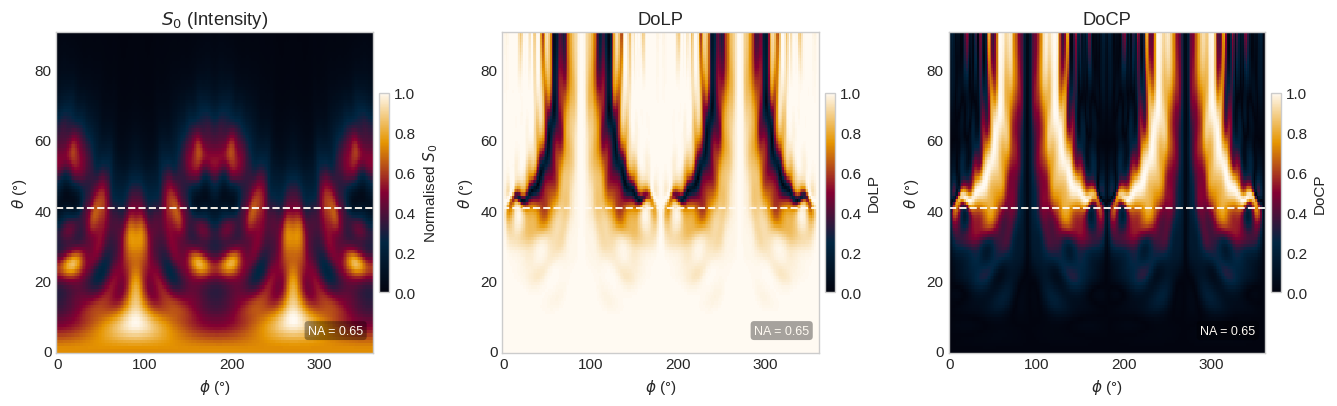

In [15]:
def compute_stokes(data, monitor_name="farfield_angles", na=0.65, n_bg=1.0):
    """
    Compute Stokes parameters and polarisation metrics from the far-field.

    Cartesian field components (Ex, Ey, Ez) are projected onto the spherical
    basis (E_theta, E_phi) using the standard physics convention for the
    e_theta and e_phi unit vectors.  Results are returned per (theta, phi)
    angle pair and as NA-weighted scalar averages.

    Parameters
    ----------
    data : td.SimulationData
    monitor_name : str
    na : float  — collection NA for weighting
    n_bg : float

    Returns
    -------
    dict  — contains S0..S3, DoLP, DoCP, DoP, psi, chi,
             theta/phi arrays, NA_mask, and averaged scalars
    """
    mon = data[monitor_name]

    theta = np.asarray(mon.theta)  # shape (n_theta,) [rad]
    phi = np.asarray(mon.phi)  # shape (n_phi,)   [rad]

    # Extract or compute spherical field components
    if hasattr(mon, "Etheta"):
        # Already in spherical basis
        dims = mon.Etheta.dims
        if "r" in dims:
            Et = mon.Etheta.isel(f=0, r=0).values
            Ep = mon.Ephi.isel(f=0, r=0).values
        else:
            Et = mon.Etheta.isel(f=0).values
            Ep = mon.Ephi.isel(f=0).values
    else:
        # Project Cartesian → spherical
        Ex = mon.Ex.isel(f=0).values.squeeze()
        Ey = mon.Ey.isel(f=0).values.squeeze()
        Ez = mon.Ez.isel(f=0).values.squeeze() if hasattr(mon, "Ez") else 0.0
        TH, PH = np.meshgrid(theta, phi, indexing="ij")
        ct, st = np.cos(TH), np.sin(TH)
        cp, sp = np.cos(PH), np.sin(PH)
        Et = ct * cp * Ex + ct * sp * Ey - st * Ez
        Ep = -sp * Ex + cp * Ey

    eps = 1e-30
    S0 = np.abs(Et) ** 2 + np.abs(Ep) ** 2
    S1 = np.abs(Et) ** 2 - np.abs(Ep) ** 2
    S2 = 2 * np.real(Et * np.conj(Ep))
    S3 = 2 * np.imag(Et * np.conj(Ep))

    DoLP = np.sqrt(S1**2 + S2**2) / (S0 + eps)
    DoCP = np.abs(S3) / (S0 + eps)
    DoP = np.sqrt(S1**2 + S2**2 + S3**2) / (S0 + eps)
    psi = 0.5 * np.arctan2(S2, S1)
    chi = 0.5 * np.arcsin(np.clip(S3 / (S0 + eps), -1, 1))

    # NA mask and S0-weighted averages within collection cone
    TH_g, _ = np.meshgrid(theta, phi, indexing="ij")
    theta_max = np.arcsin(min(na / n_bg, 0.9999))
    NA_mask = TH_g <= theta_max
    w = np.sin(TH_g)  # solid-angle weight sin(θ)

    def wavg(arr):
        wt = (S0 * w * NA_mask).sum() + eps
        return float((arr * S0 * w * NA_mask).sum() / wt)

    return {
        "S0": S0,
        "S1": S1,
        "S2": S2,
        "S3": S3,
        "DoLP": DoLP,
        "DoCP": DoCP,
        "DoP": DoP,
        "psi": psi,
        "chi": chi,
        "theta": theta,
        "phi": phi,
        "NA_mask": NA_mask,
        "DoLP_avg": wavg(DoLP),
        "DoCP_avg": wavg(DoCP),
        "DoP_avg": wavg(DoP),
        "psi_avg": wavg(psi),
        "theta_max_deg": np.rad2deg(theta_max),
    }


def plot_stokes(pol, na):
    """Plot S0 intensity, DoLP, and DoCP on θ-φ heatmaps."""
    theta_deg = np.rad2deg(pol["theta"])
    phi_deg = np.rad2deg(pol["phi"])

    panels = [
        (
            "$S_0$ (Intensity)",
            pol["S0"] / pol["S0"].max(),
            mono_cmap,
            0,
            1,
            "Normalised $S_0$",
        ),
        ("DoLP", pol["DoLP"], mono_cmap, 0, 1, "DoLP"),
        ("DoCP", pol["DoCP"], mono_cmap, 0, 1, "DoCP"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
    for ax, (title, arr, cmap, vmin, vmax, cbar_label) in zip(axes, panels):
        im = ax.pcolormesh(
            phi_deg, theta_deg, arr, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto"
        )
        cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label(cbar_label)
        ax.axhline(pol["theta_max_deg"], color=WHITE, ls="--", lw=1.4, alpha=0.95)
        ax.set_xlabel("$\\phi$ (°)")
        ax.set_ylabel("$\\theta$ (°)")
        ax.set_title(title)
        ax.text(
            0.97,
            0.05,
            f"NA = {na:.2f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            color=WHITE,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.28", fc=(0, 0, 0, 0.35), ec="none"),
        )
    plt.tight_layout()
    plt.show()


print("── Polarisation analysis ────────────────────────────────────────────────")
pol = compute_stokes(data, na=NA)

print(f"  DoLP  (linear)  = {pol['DoLP_avg']:.3f}")
print(f"  DoCP  (circular)= {pol['DoCP_avg']:.3f}")
print(f"  DoP   (total)   = {pol['DoP_avg']:.3f}")
print(f"  ψ (orientation) = {np.rad2deg(pol['psi_avg']):.1f}°")

plot_stokes(pol, NA)

<a id='summary'></a>
## 11. Results Summary

In [16]:
w = 62  # column width
print("=" * w)
print("  DIAMOND PHOTONIC CRYSTAL NANOCAVITY – SIMULATION RESULTS")
print("=" * w)

print("\n  Structure")
print(f"    Slab thickness         : {THICKNESS_UM * 1e3:.1f} nm")
print(f"    Sidewall angle         : {SIDEWALL_ANGLE_DEG}°")
print(f"    Diamond index at λ₀    : {float(n_diamond(wavelength_lockin)):.4f}")

print("\n  Resonance (from scout stage)")
print(f"    Resonance wavelength λ₀: {wavelength_lockin * 1e3:.3f} nm")
print(f"    Quality factor  Q      : {q_results['Q']:.0f}")
print(f"    Energy decay time τ    : {q_results['decay_time_ps']:.2f} ps")

print("\n  Near-Field Confinement")
print(f"    1/e² width w_x         : {conf['w_x_um'] * 1e3:.0f} nm")
print(f"    1/e² width w_y         : {conf['w_y_um'] * 1e3:.0f} nm")
print(
    f"    Eff. mode area A_eff   : {conf['A_eff_um2']:.4f} µm²"
    f" = {conf['A_eff_lambda2']:.3f} λ²"
)

print("\n  Mode Volume and Purcell Enhancement")
print(f"    Eff. mode volume V_eff : {V_eff:.4f} µm³ = {V_norm:.3f} × (λ/2n)³")
print(f"    Purcell factor  F_P    : {F_P:.1f}")

print(f"\n  Collection (NA = {NA})")
print(f"    Collection efficiency η: {eta_NA * 100:.1f}%")

print("\n  Far-Field Polarisation")
print(f"    DoLP (linear)          : {pol['DoLP_avg']:.3f}")
print(f"    DoCP (circular)        : {pol['DoCP_avg']:.3f}")
print(f"    DoP  (total)           : {pol['DoP_avg']:.3f}")
print(f"    Orientation angle ψ    : {np.rad2deg(pol['psi_avg']):.1f}°")

print("\n" + "=" * w)

  DIAMOND PHOTONIC CRYSTAL NANOCAVITY – SIMULATION RESULTS

  Structure
    Slab thickness         : 136.0 nm
    Sidewall angle         : 15.6°
    Diamond index at λ₀    : 2.4115

  Resonance (from scout stage)
    Resonance wavelength λ₀: 639.305 nm
    Quality factor  Q      : 67767
    Energy decay time τ    : 46.00 ps

  Near-Field Confinement
    1/e² width w_x         : 1568 nm
    1/e² width w_y         : 197 nm
    Eff. mode area A_eff   : 1.6626 µm² = 4.068 λ²

  Mode Volume and Purcell Enhancement
    Eff. mode volume V_eff : 0.1204 µm³ = 51.720 × (λ/2n)³
    Purcell factor  F_P    : 796.6

  Collection (NA = 0.65)
    Collection efficiency η: 31.2%

  Far-Field Polarisation
    DoLP (linear)          : 0.952
    DoCP (circular)        : 0.221
    DoP  (total)           : 1.000
    Orientation angle ψ    : 0.5°



## Conclusion

This notebook demonstrates a fabrication-aware Tidy3D workflow for simulating and characterizing a diamond photonic crystal nanobeam cavity from notebook-local geometry specifications. For this fabricated cavity instance, the broadband scout plus narrowband characterization workflow predicts the cavity resonance, Q factor, mode volume, Purcell enhancement, collection efficiency, and polarization / far-field response in a compact two-stage simulation procedure.

**Key takeaways:**

- A broadband scout simulation combined with Tidy3D [`ResonanceFinder`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.resonance.ResonanceFinder.html) provides an efficient route to the cavity resonance and Q estimate.
- The narrowband characterization stage resolves near-field confinement, mode volume, Purcell enhancement, collection efficiency, and polarization response for the modeled fabricated structure.
- Because the workflow is built from notebook-local fabrication geometry specifications, it can be reused to compare multiple cavity realizations or incorporated into larger fabrication-variation studies.

---

## References

1. Faraon, A. *et al.* "Resonant enhancement of the zero-phonon emission from a colour centre in a diamond cavity." *Nature Photonics* **5**, 301–305 (2011). doi:10.1038/nphoton.2011.52.
2. Riedrich-Möller, J. *et al.* "One- and two-dimensional photonic crystal microcavities in single crystal diamond." *Nature Nanotechnology* **7**, 69–74 (2012). doi:10.1038/nnano.2011.190.
3. Zaitsev, A. M. *Optical Properties of Diamond: A Data Handbook.* Springer, Berlin, Heidelberg (2001). doi:10.1007/978-3-662-04548-0.
4. Almutlaq, J., Buzzi, A., Khaykin, A., Li, L., Yzaguirre, W., Sirotin, M., Gilbert, G., Clark, G., and Englund, D. "Foundry-Enabled Patterning of Diamond Quantum Microchiplets for Scalable Quantum Photonics." arXiv:2601.20025 [quant-ph] (2026). doi:10.48550/arXiv.2601.20025.
5. Flexcompute. *Tidy3D Documentation.* https://docs.flexcompute.com/projects/tidy3d/en/latest/ (accessed 2026-04-06).
6. Purcell, E. M. "Spontaneous emission probabilities at radio frequencies." In *Proceedings of the American Physical Society*, *Physical Review* **69**, 674 (1946). doi:10.1103/PhysRev.69.674.2.